### Importing Required Libraries

In [89]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

### Loading the Dataset

In [90]:
data = pd.read_csv('telco_csv.csv')
data.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,2,13,44,1,9,64,4,5,0,0,...,0,1,0,3.70,0.00,0.0,7.50,0.0,0,1
1,3,11,33,1,7,136,5,5,0,0,...,1,1,1,4.40,20.75,0.0,15.25,35.7,0,4
2,3,68,52,1,24,116,1,29,0,1,...,1,0,1,18.15,18.00,0.0,30.25,0.0,0,3
3,2,33,33,0,12,33,2,0,0,1,...,0,0,0,9.45,0.00,0.0,0.00,0.0,0,1
4,2,23,30,1,9,30,1,2,0,0,...,0,1,1,6.30,0.00,0.0,0.00,0.0,0,3


### Initial Data Exploration

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1000 non-null   int64  
 1   tenure    1000 non-null   int64  
 2   age       1000 non-null   int64  
 3   marital   1000 non-null   int64  
 4   address   1000 non-null   int64  
 5   income    1000 non-null   int64  
 6   ed        1000 non-null   int64  
 7   employ    1000 non-null   int64  
 8   retire    1000 non-null   int64  
 9   gender    1000 non-null   int64  
 10  reside    1000 non-null   int64  
 11  tollfree  1000 non-null   int64  
 12  equip     1000 non-null   int64  
 13  callcard  1000 non-null   int64  
 14  wireless  1000 non-null   int64  
 15  multline  1000 non-null   int64  
 16  voice     1000 non-null   int64  
 17  pager     1000 non-null   int64  
 18  internet  1000 non-null   int64  
 19  callid    1000 non-null   int64  
 20  callwait  1000 non-null   int64

In [92]:
# to check the statistical distribution of data and get idea of presence of outliers
data.describe(include = 'all', percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.9999]).T


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.99%,max
region,1000.0,2.0220,0.816200,1.0,1.00,1.0000,1.000,1.0,2.000,3.0000,3.000,3.0000,3.0000,3.000000,3.00
tenure,1000.0,35.5260,21.359812,1.0,1.00,4.0000,7.000,17.0,34.000,54.0000,66.000,70.0000,72.0000,72.000000,72.00
age,1000.0,41.6840,12.558816,18.0,20.00,23.0000,26.000,32.0,40.000,51.0000,59.000,64.0000,70.0100,76.900100,77.00
marital,1000.0,0.4950,0.500225,0.0,0.00,0.0000,0.000,0.0,0.000,1.0000,1.000,1.0000,1.0000,1.000000,1.00
address,1000.0,11.5510,10.086681,0.0,0.00,0.0000,1.000,3.0,9.000,18.0000,26.100,31.0000,43.0000,54.400600,55.00
income,1000.0,77.5350,107.044165,9.0,10.99,18.0000,21.000,29.0,47.000,83.0000,155.400,232.2500,460.4800,1614.353700,1668.00
ed,1000.0,2.6710,1.222397,1.0,1.00,1.0000,1.000,2.0,3.000,4.0000,4.000,5.0000,5.0000,5.000000,5.00
employ,1000.0,10.9870,10.082087,0.0,0.00,0.0000,0.000,3.0,8.000,17.0000,25.000,31.0000,40.0100,46.800200,47.00
retire,1000.0,0.0470,0.211745,0.0,0.00,0.0000,0.000,0.0,0.000,0.0000,0.000,0.0000,1.0000,1.000000,1.00
gender,1000.0,0.5170,0.499961,0.0,0.00,0.0000,0.000,0.0,1.000,1.0000,1.000,1.0000,1.0000,1.000000,1.00


In [93]:
# chekc the presence of outliers
data[data['income']>460.4800].shape[0]

10

### Data Quality Checks

In [94]:
# if columns names are not proper
data.columns = [col.strip().lower().replace(' ','_') for col in data.columns]   

In [95]:
# data type of all the columns is correct here so no need type casting. 
# note: sometimes dtype of numeric feature shows as object due to presence of unknowns or special characters so we have to detact them :
#   value_to_find = ['unknown', 999, '?']
#   print('Columns that have encoded missings:',list(data.columns[data.isin(value_to_find).any()]))

# tp treat use :
# data[col] = pd.to_numeric(data[col], errors='coerce'), it will make non numeric values from object column to nan and change data type to float64  or 
# also can use data['col'] = data[col].str.replace('[₹$,%,]', '', regex=True), it will make special char to nan 


In [96]:
data.isna().sum()  # or we can get idea of nulls from data.info result

# if nulls present we will drop or treat nulls based on % of nulls & business importance, if feature is: 
# numeric ->  1-5 % impute safely, 5-15% impute (if skewed then median else mean), 20-25% knn imputation or drop based on importance, > 25- 30 usually drop
# categorical --> impute (mode) safely if nulls are less, if high then create separate category ( unknowns or 999 or ...) for the missings

region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
employ      0
retire      0
gender      0
reside      0
tollfree    0
equip       0
callcard    0
wireless    0
multline    0
voice       0
pager       0
internet    0
callid      0
callwait    0
forward     0
confer      0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
ebill       0
custcat     0
dtype: int64

In [97]:
data.duplicated().sum()

# if duplicates are present in data we will remove duplicates using .drop_duplicates(keep = 'first' or 'last' based on dates) function 

0

In [98]:
# columns names are correct
# no duplicates
# no missings
# may have outliers
# region and custcat columns are nominal in nature and already encoded as numeical but due to their nominal nature we have to apply ordinal encoding on them, i mean we have to apply onehot encoding for them 
# prerequisites for K-means : we have to standarize data   

### Outlier Detection and Treatment

In [99]:
# Handling Outliers
def outliers(x): 
    if x.dtype in (['int64', 'float64']):
         x = x.clip(lower = x.quantile(0.01)- 0.5* x.std() , upper = x.quantile(0.99)+ 0.5 * x.std()) 
         return x 

In [100]:
data = data.apply(outliers)

In [101]:
data.describe(percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.9999]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.99%,max
region,1000.0,2.022000,0.816200,1.0,1.00,1.0000,1.000,1.0,2.000,3.0000,3.000,3.0000,3.0000,3.000000,3.000000
tenure,1000.0,35.526000,21.359812,1.0,1.00,4.0000,7.000,17.0,34.000,54.0000,66.000,70.0000,72.0000,72.000000,72.000000
age,1000.0,41.683289,12.556836,18.0,20.00,23.0000,26.000,32.0,40.000,51.0000,59.000,64.0000,70.0100,76.260496,76.289408
marital,1000.0,0.495000,0.500225,0.0,0.00,0.0000,0.000,0.0,0.000,1.0000,1.000,1.0000,1.0000,1.000000,1.000000
address,1000.0,11.543087,10.055525,0.0,0.00,0.0000,1.000,3.0,9.000,18.0000,26.100,31.0000,43.0000,48.043341,48.043341
income,1000.0,74.298019,80.345473,9.0,10.99,18.0000,21.000,29.0,47.000,83.0000,155.400,232.2500,460.4800,514.002082,514.002082
ed,1000.0,2.671000,1.222397,1.0,1.00,1.0000,1.000,2.0,3.000,4.0000,4.000,5.0000,5.0000,5.000000,5.000000
employ,1000.0,10.985051,10.075305,0.0,0.00,0.0000,0.000,3.0,8.000,17.0000,25.000,31.0000,40.0100,45.045944,45.051044
retire,1000.0,0.047000,0.211745,0.0,0.00,0.0000,0.000,0.0,0.000,0.0000,0.000,0.0000,1.0000,1.000000,1.000000
gender,1000.0,0.517000,0.499961,0.0,0.00,0.0000,0.000,0.0,1.000,1.0000,1.000,1.0000,1.0000,1.000000,1.000000


### Encoding Categorical Variables

In [102]:
data['region'].unique(), data['custcat'].unique()

(array([2, 3, 1], dtype=int64), array([1, 4, 3, 2], dtype=int64))

In [103]:
data[['region', 'custcat']][:3]

,region,custcat
0,2,1
1,3,4
2,3,3


In [104]:
from sklearn.preprocessing import OneHotEncoder

In [105]:
ohe = OneHotEncoder(drop = 'first').fit(data[['region', 'custcat']])   # even they are given as numerical form but they are nominal in nature so let them consider as  categorical and apply onehot encoding on them 

In [106]:
ohe_df = pd.DataFrame(ohe.transform(data[['region', 'custcat']]).toarray(), columns = ohe.get_feature_names_out())
ohe_df

,region_2,region_3,custcat_2,custcat_3,custcat_4
0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0
997,0.0,1.0,0.0,0.0,1.0
998,0.0,1.0,0.0,1.0,0.0


In [107]:
data = data[data.columns.difference(['region', 'custcat'])]
data.columns

Index(['address', 'age', 'callcard', 'callid', 'callwait', 'cardmon', 'confer',
       'ebill', 'ed', 'employ', 'equip', 'equipmon', 'forward', 'gender',
       'income', 'internet', 'longmon', 'marital', 'multline', 'pager',
       'reside', 'retire', 'tenure', 'tollfree', 'tollmon', 'voice',
       'wireless', 'wiremon'],
      dtype='object')

In [108]:
telco_final = pd.concat([data, ohe_df], axis = 1)
telco_final.head()

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,tollfree,tollmon,voice,wireless,wiremon,region_2,region_3,custcat_2,custcat_3,custcat_4
0,9.0,44.0,1,0,0,7.50,0,0,4,5.0,...,0,0.00,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,7.0,33.0,1,1,1,15.25,1,0,5,5.0,...,1,20.75,1,1,35.7,0.0,1.0,0.0,0.0,1.0
2,24.0,52.0,1,1,1,30.25,1,0,1,29.0,...,1,18.00,0,0,0.0,0.0,1.0,0.0,1.0,0.0
3,12.0,33.0,0,0,0,0.00,0,0,2,0.0,...,0,0.00,0,0,0.0,1.0,0.0,0.0,0.0,0.0
4,9.0,30.0,0,1,0,0.00,1,0,1,2.0,...,0,0.00,0,0,0.0,1.0,0.0,0.0,1.0,0.0


### KNN with manually feature reduction, using vif, correlation 

### Feature Engineering 
    Note: In Unsupervised Learning we did not have target variable so here we did not use RFE and SelectKBest for feature reduction.

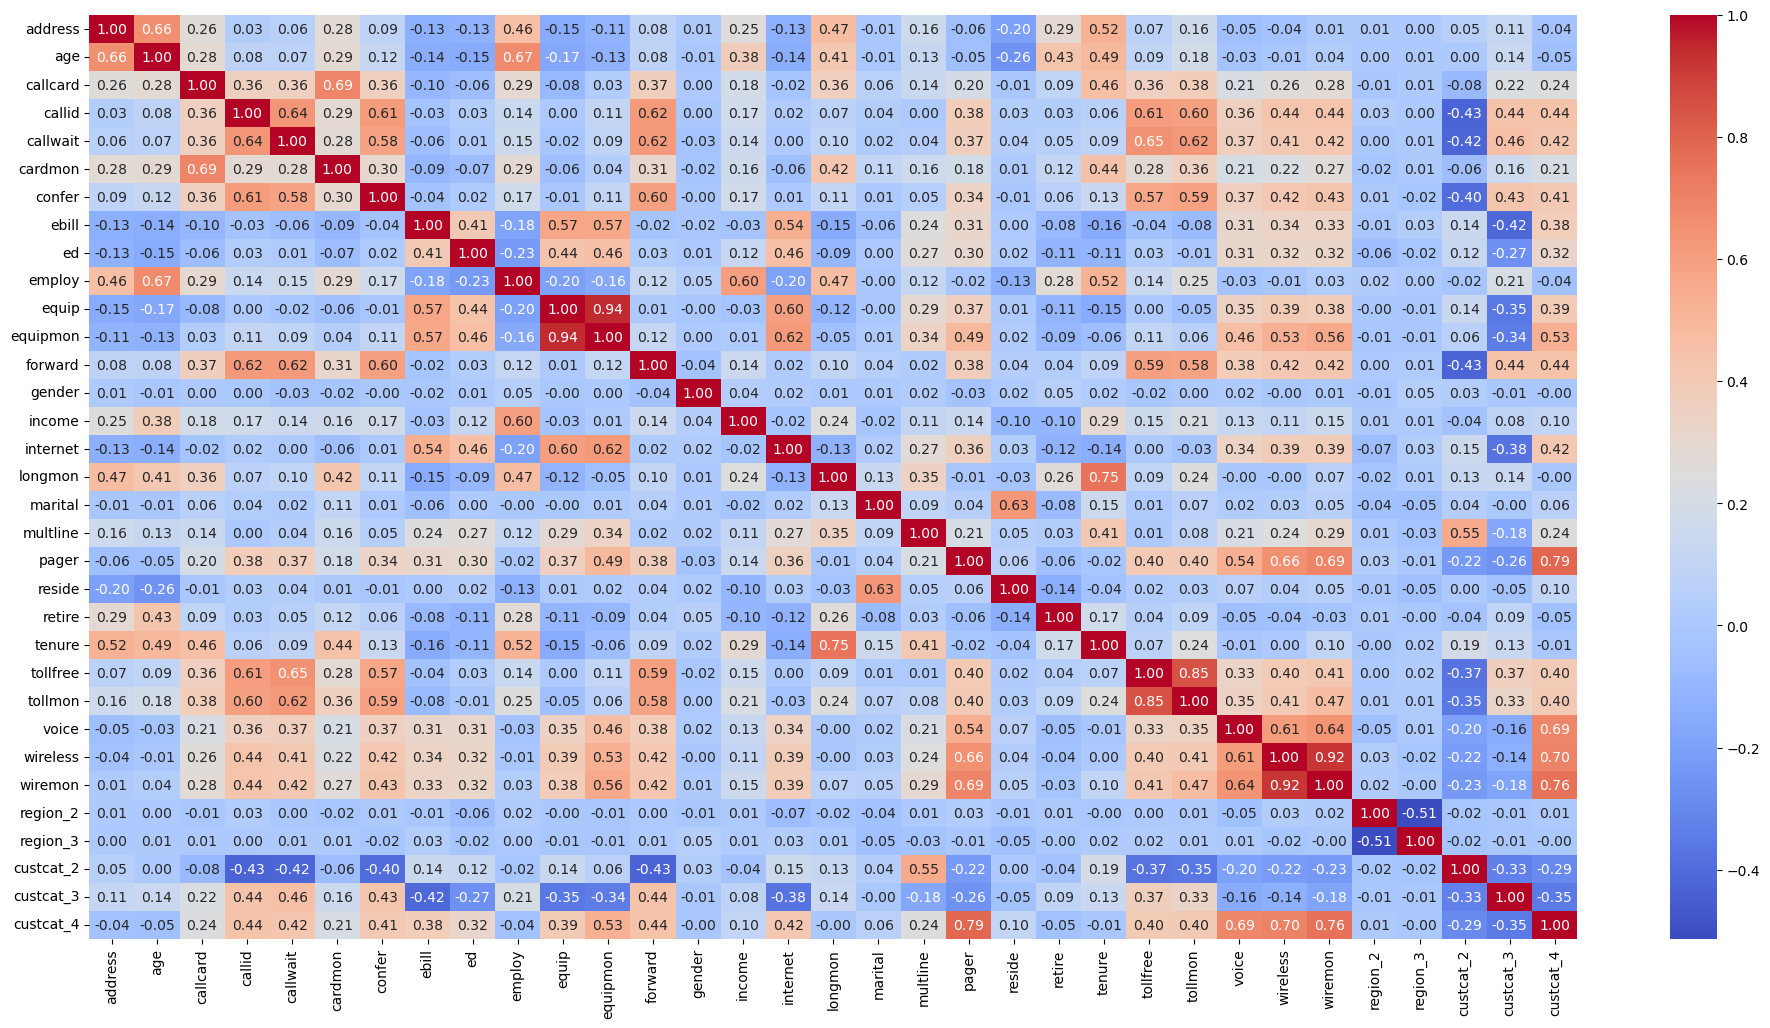

In [109]:
plt.figure(figsize=(24,12))
sns.heatmap(telco_final.corr(numeric_only=True), fmt = '.2f',annot = True, cmap = 'coolwarm')
plt.show()

In [110]:
cv = telco_final.std()/telco_final.mean()
cv.sort_values(ascending = True)

age          0.301244
ed           0.457655
tenure       0.601244
reside       0.611514
callcard     0.689494
longmon      0.827927
address      0.871130
employ       0.917183
gender       0.967042
cardmon      0.995027
confer       0.996506
marital      1.010556
forward      1.014607
callwait     1.030979
callid       1.039270
multline     1.051841
tollfree     1.053952
income       1.081395
tollmon      1.224124
equip        1.261850
ebill        1.302734
internet     1.311149
equipmon     1.339787
region_3     1.381624
region_2     1.412801
voice        1.513858
wireless     1.542971
custcat_3    1.600400
wiremon      1.681694
pager        1.683524
custcat_4    1.800147
custcat_2    1.900502
retire       4.505207
dtype: float64

In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [112]:
telco_final.columns

Index(['address', 'age', 'callcard', 'callid', 'callwait', 'cardmon', 'confer',
       'ebill', 'ed', 'employ', 'equip', 'equipmon', 'forward', 'gender',
       'income', 'internet', 'longmon', 'marital', 'multline', 'pager',
       'reside', 'retire', 'tenure', 'tollfree', 'tollmon', 'voice',
       'wireless', 'wiremon', 'region_2', 'region_3', 'custcat_2', 'custcat_3',
       'custcat_4'],
      dtype='object')

In [113]:
print(sorted(list(telco_final.tenure.unique()),reverse = True))

[72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


In [114]:
x_final = telco_final[telco_final.columns.difference(['equipmon','age','wiremon','tenure','tollmon','custcat_4','ed','callcard','reside','employ'])]
vif_df = pd.DataFrame()
vif_df['Features'] = x_final.columns
vif_df['vif_score'] = [variance_inflation_factor(x_final.values, i) for i in range(x_final.shape[1])]
vif_df = vif_df.sort_values(by = 'vif_score', ascending = False).reset_index(drop=True)
vif_df

,Features,vif_score
0,callwait,4.868329
1,callid,4.722915
2,forward,4.713766
3,multline,4.398325
4,confer,4.372310
5,longmon,4.356799
6,tollfree,4.137576
7,custcat_3,4.045319
8,wireless,3.561298
9,pager,3.465665


In [115]:
x_final.shape

(1000, 23)

### Feature Scaling

In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
ss = StandardScaler().fit(x_final)
telco_scaled = pd.DataFrame(ss.transform(x_final), columns = x_final.columns)
telco_scaled.head()

,address,callid,callwait,cardmon,confer,custcat_2,custcat_3,ebill,equip,forward,...,longmon,marital,multline,pager,region_2,region_3,retire,tollfree,voice,wireless
0,-0.253031,-0.962695,-0.970437,-0.454483,-1.004008,-0.52644,-0.625156,-0.768001,-0.792884,1.014099,...,-0.822937,1.010051,-0.95119,-0.594289,1.412095,-0.724148,-0.222076,-0.949284,-0.660895,-0.648425
1,-0.452026,1.038750,1.030464,0.114902,0.996008,-0.52644,-0.625156,-0.768001,-0.792884,1.014099,...,-0.750003,1.010051,-0.95119,1.682682,-0.708168,1.380933,-0.222076,1.053425,1.513101,1.542199
2,1.239433,1.038750,1.030464,1.216938,0.996008,-0.52644,1.599600,-0.768001,-0.792884,-0.986097,...,0.682614,1.010051,-0.95119,-0.594289,-0.708168,1.380933,-0.222076,1.053425,-0.660895,-0.648425
3,0.045462,-0.962695,-0.970437,-1.005501,-1.004008,-0.52644,-0.625156,-0.768001,-0.792884,-0.986097,...,-0.223842,-0.990050,-0.95119,-0.594289,1.412095,-0.724148,-0.222076,-0.949284,-0.660895,-0.648425
4,-0.253031,1.038750,-0.970437,-1.005501,0.996008,-0.52644,1.599600,-0.768001,-0.792884,1.014099,...,-0.552042,1.010051,-0.95119,-0.594289,1.412095,-0.724148,-0.222076,-0.949284,-0.660895,-0.648425


In [118]:
import warnings
warnings.filterwarnings('ignore')

In [119]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [120]:
k = []
wcss = []
sil_score = []
for i in range(2,15):
    km = KMeans(n_clusters=i, random_state=123).fit(telco_scaled)
    km_labels = km.predict(telco_scaled)  
    score = silhouette_score(telco_scaled, km_labels)
    k.append(i)
    wcss.append(km.inertia_)
    sil_score.append(score)
    print('K:',i, ', Silhouette Score:',score, ', WCSS:',km.inertia_)

K: 2 , Silhouette Score: 0.18124399686486392 , WCSS: 18746.422699706072
K: 3 , Silhouette Score: 0.19420167363557062 , WCSS: 16355.363673628694
K: 4 , Silhouette Score: 0.1515081120281675 , WCSS: 15334.165081303585
K: 5 , Silhouette Score: 0.1411928994771405 , WCSS: 14841.387999849889
K: 6 , Silhouette Score: 0.11305388242856904 , WCSS: 14246.84722466805
K: 7 , Silhouette Score: 0.12021377953488512 , WCSS: 13794.260713332467
K: 8 , Silhouette Score: 0.14004425066324938 , WCSS: 12884.091195410248
K: 9 , Silhouette Score: 0.1306093469136987 , WCSS: 12503.600525280048
K: 10 , Silhouette Score: 0.11129719711438486 , WCSS: 12220.094642940081
K: 11 , Silhouette Score: 0.10812302901534657 , WCSS: 12035.85098770048
K: 12 , Silhouette Score: 0.10850516876343588 , WCSS: 11894.765295346879
K: 13 , Silhouette Score: 0.1093831303825167 , WCSS: 11674.334711197236
K: 14 , Silhouette Score: 0.10709115616543789 , WCSS: 11514.772818093345


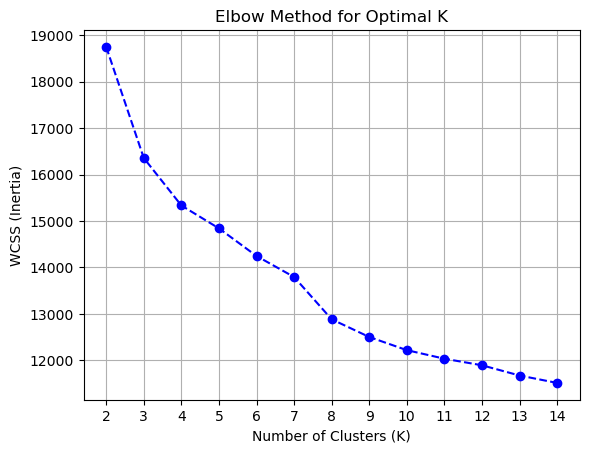

In [121]:
plt.plot(k,wcss,marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.xticks(k)
plt.show()

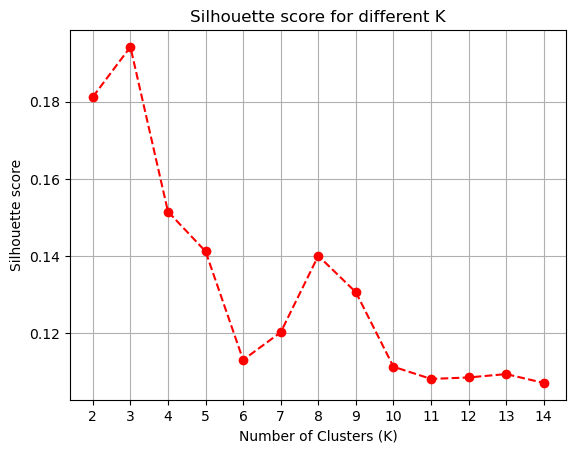

In [122]:
plt.plot(k,sil_score,marker='o', linestyle='--', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for different K')
plt.grid(True)
plt.xticks(k)
plt.show()

In [123]:
### with the mannual feature reduction we can't able to get the better silhoutte score as we achive max to max 19% that show s weaker cluser saperatin 

In [124]:
# so as per the elbow method and sillhoute score, the optimal number of clusters are 3

In [125]:
km_model = KMeans(n_clusters=3, random_state = 123).fit(telco_scaled)
km_pred = km_model.predict(telco_scaled)
km_pred[:10]

array([2, 0, 1, 2, 1, 1, 2, 0, 1, 2])

In [126]:
print('silhouette_score :',silhouette_score(telco_scaled, km_pred))
print('inertia :',km_model.inertia_)

silhouette_score : 0.19420167363557062
inertia : 16355.363673628697


In [127]:
km_model.cluster_centers_   # centroids of each cluster. here data in not 2d so each centroid  has 23 points

array([[-7.74945852e-02,  7.29583860e-01,  7.13247863e-01,
         3.67589458e-01,  6.95192553e-01, -4.96854867e-01,
        -6.16112724e-01,  6.96204197e-01,  7.18468359e-01,
         7.45780407e-01, -1.48053079e-03,  1.77204539e-01,
         7.54170585e-01, -2.10103642e-02,  1.07566354e-01,
         3.91953663e-01,  1.39574629e+00,  2.44433525e-02,
        -2.24541998e-02, -8.76243470e-02,  7.11499183e-01,
         1.20379242e+00,  1.28395492e+00],
       [ 1.81155356e-01,  7.02843301e-01,  7.22632950e-01,
         2.48557490e-01,  6.60340947e-01, -5.26440128e-01,
         1.55292639e+00, -6.66668003e-01, -5.77418336e-01,
         6.99383228e-01, -1.30285117e-02,  1.21554270e-01,
        -5.89066327e-01,  2.02936804e-01,  3.00714337e-03,
        -2.86022087e-01, -4.19137842e-01, -1.12981825e-02,
        -1.75472505e-02,  1.41387453e-01,  5.98263946e-01,
        -2.65622691e-01, -2.34810368e-01],
       [-6.99717173e-02, -8.13014559e-01, -8.16521363e-01,
        -3.45116344e-01, -7.6

In [128]:
km_model.transform(telco_scaled)  # compute distance of each data point from each cluster centroid

array([[6.07317078, 4.80091105, 3.57817094],
       [3.84011726, 4.79746263, 6.28678074],
       [5.94663528, 3.35426295, 5.63479696],
       ...,
       [6.88882435, 8.52913344, 9.38276667],
       [5.41452694, 3.34597891, 6.16132289],
       [6.12581869, 6.52345245, 3.63453904]])

In [129]:
from collections import Counter

In [130]:
Counter(km_pred)

Counter({2: 468, 1: 286, 0: 246})

### Dimensionality Reduction using PCA

#### whenever we apply pca we have to give all the scaled data to pca

In [131]:
from sklearn.decomposition import PCA

In [132]:
# standardizated telco_final data with all the features
ss_telco = StandardScaler().fit(telco_final)
telco_final_scaled = pd.DataFrame(ss_telco.transform(telco_final), columns = telco_final.columns)
telco_final_scaled

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,tollfree,tollmon,voice,wireless,wiremon,region_2,region_3,custcat_2,custcat_3,custcat_4
0,-0.253031,0.184590,0.689149,-0.962695,-0.970437,-0.454483,-1.004008,-0.768001,1.087753,-0.594329,...,-0.949284,-0.817320,-0.660895,-0.648425,-0.594936,1.412095,-0.724148,-0.526440,-0.625156,-0.555788
1,-0.452026,-0.691865,0.689149,1.038750,1.030464,0.114902,0.996008,-0.768001,1.906227,-0.594329,...,1.053425,0.474004,1.513101,1.542199,1.254508,-0.708168,1.380933,-0.526440,-0.625156,1.799247
2,1.239433,0.822012,0.689149,1.038750,1.030464,1.216938,0.996008,-0.768001,-1.367671,1.788925,...,1.053425,0.302865,-0.660895,-0.648425,-0.594936,-0.708168,1.380933,-0.526440,1.599600,-0.555788
3,0.045462,-0.691865,-1.451065,-0.962695,-0.970437,-1.005501,-1.004008,-0.768001,-0.549196,-1.090840,...,-0.949284,-0.817320,-0.660895,-0.648425,-0.594936,1.412095,-0.724148,-0.526440,-0.625156,-0.555788
4,-0.253031,-0.930898,-1.451065,1.038750,-0.970437,-1.005501,0.996008,-0.768001,-1.367671,-0.892236,...,-0.949284,-0.817320,-0.660895,-0.648425,-0.594936,1.412095,-0.724148,-0.526440,1.599600,-0.555788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.148509,-0.213798,-1.451065,-0.962695,-0.970437,-1.005501,-1.004008,1.302082,0.269278,-1.090840,...,-0.949284,-0.817320,-0.660895,-0.648425,-0.594936,-0.708168,1.380933,-0.526440,-0.625156,-0.555788
996,-0.949514,-0.612187,-1.451065,-0.962695,-0.970437,-1.005501,-1.004008,-0.768001,1.906227,-0.594329,...,-0.949284,-0.817320,-0.660895,-0.648425,-0.594936,-0.708168,-0.724148,-0.526440,-0.625156,-0.555788
997,2.831394,1.379756,0.689149,1.038750,1.030464,1.621018,0.996008,1.302082,1.906227,2.186134,...,1.053425,1.174120,1.513101,1.542199,2.813843,-0.708168,1.380933,-0.526440,-0.625156,1.799247
998,0.642447,0.582979,0.689149,1.038750,1.030464,0.849593,0.996008,-0.768001,-0.549196,1.093809,...,1.053425,1.267468,1.513101,-0.648425,-0.594936,-0.708168,1.380933,-0.526440,1.599600,-0.555788


In [133]:
### initially build pca model on all features and after that choose the optimal number of pc's based on cumulative explianed varienve  

In [134]:
pca = PCA(n_components = 10, random_state=42).fit(telco_final_scaled)
pca

PCA(n_components=10, random_state=42)

##### Rule of Thumb to choose the number of principal components that will show max variencd :
* cumulative explained varience is > 70-80% 
* individual explained varience is around 0.7-0.8% 

In [135]:
# cumulatice explained varience 
pca.explained_variance_ratio_.cumsum()

array([0.22281541, 0.38560371, 0.48853822, 0.54426336, 0.59068809,
       0.6281239 , 0.66405192, 0.6966419 , 0.72702487, 0.7538291 ])

In [136]:
# individual explained varience
pca.explained_variance_

array([7.3602687 , 5.3773915 , 3.40023906, 1.84077019, 1.53354961,
       1.2366186 , 1.1868115 , 1.07654577, 1.00364155, 0.8854252 ])

In [137]:
pca_dim = pd.DataFrame(pca.transform(telco_final_scaled), columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10'])
pca_dim

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-2.261921,-0.097875,-0.983094,0.319992,1.503737,0.619699,0.368028,-0.957406,0.872503,-0.620747
1,3.448810,-0.760404,-2.424567,1.846295,-1.289493,2.170587,0.469216,-1.042057,0.584105,1.204437
2,0.275714,4.351712,0.071896,0.433780,-1.589220,0.594590,-0.397880,0.333976,-0.458822,-1.137247
3,-3.483588,-0.382004,-0.890922,-1.100522,1.548114,0.369736,0.615252,-0.327885,-1.325608,0.472558
4,-1.934877,0.744764,-2.962412,1.306264,1.606680,0.142488,-0.141601,0.677748,1.228931,-0.066216
...,...,...,...,...,...,...,...,...,...,...
995,-2.805664,-2.789537,-0.861785,-1.025310,-1.434127,0.465920,0.231529,0.814129,-0.374568,-0.788524
996,-2.875822,-2.398625,-0.845496,-1.546895,0.007266,0.111289,-0.373564,0.523219,-0.642232,-0.574003
997,6.908926,0.590213,4.485407,-2.531347,-1.378063,2.685020,-2.541980,-0.480627,-0.427642,-0.792016
998,1.500433,4.014967,-0.488329,-0.839275,-1.770257,-0.644974,-0.599741,-0.126773,-1.002954,-0.327960


In [138]:
k = []
wcss = []
sil_score = []
for i in range(2,15):
    km = KMeans(n_clusters=i, random_state=123).fit(pca_dim)
    km_labels = km.predict(pca_dim)  
    score = silhouette_score(pca_dim, km_labels)
    k.append(i)
    wcss.append(km.inertia_)
    sil_score.append(score)
    print('K:',i, ', Silhouette Score:',score, ', WCSS:',km.inertia_)

K: 2 , Silhouette Score: 0.2215329078406374 , WCSS: 19224.24127157347
K: 3 , Silhouette Score: 0.23948797432654123 , WCSS: 15507.651592975757
K: 4 , Silhouette Score: 0.2149062444427545 , WCSS: 14000.712782085942
K: 5 , Silhouette Score: 0.20267827251537376 , WCSS: 13191.602012489704
K: 6 , Silhouette Score: 0.19138481784995753 , WCSS: 12205.237607112085
K: 7 , Silhouette Score: 0.19004589311771974 , WCSS: 11505.689297179299
K: 8 , Silhouette Score: 0.16301042400001392 , WCSS: 11031.91034889909
K: 9 , Silhouette Score: 0.16156585839006765 , WCSS: 10682.736153935497
K: 10 , Silhouette Score: 0.16583137055606256 , WCSS: 10149.225333053188
K: 11 , Silhouette Score: 0.1250668350898409 , WCSS: 10309.154981302874
K: 12 , Silhouette Score: 0.14101002258911582 , WCSS: 9700.433882912906
K: 13 , Silhouette Score: 0.12101412896717671 , WCSS: 9798.402691478248
K: 14 , Silhouette Score: 0.1231951967316823 , WCSS: 9619.938125723847


In [139]:
km_pca_model = KMeans(n_clusters=3, random_state = 123).fit(pca_dim)
km_pca_pred = km_pca_model.predict(pca_dim)
km_pca_pred[:10]

array([2, 0, 1, 2, 1, 1, 2, 0, 1, 2])

In [140]:
print('silhouette_score :',silhouette_score(pca_dim, km_pca_pred))  # as compared to normal feature reduction ,here in with pca sillhoute score is improved

silhouette_score : 0.23948797432654123


### to get the explainability or the features on the place of principle components, we take the features that have strong corr with principle component

In [141]:
# because if a feature has strong correlation with a principal component then that featuer will never correlate with other features because all pc's are independent of each others 

In [142]:
loadings = pd.DataFrame((pca.components_.T * np.sqrt(pca.explained_variance_)).T, columns = telco_final_scaled.columns).T
loadings.columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9','PC10']

In [143]:
loadings.to_excel('loadings.xlsx')

In [144]:
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
address,0.113056,0.508275,0.502995,-0.176967,0.025930,0.069266,0.125232,0.117532,0.126835,-0.010577
age,0.141744,0.564743,0.502487,-0.287794,0.033500,0.211726,0.107042,0.170900,0.167007,-0.063859
callcard,0.492408,0.415882,0.189036,0.167169,-0.052999,-0.242364,0.125456,-0.346047,-0.134160,-0.326096
callid,0.695603,0.252684,-0.330995,-0.006231,0.002855,-0.066189,-0.113619,0.088819,0.001924,-0.037558
callwait,0.687068,0.282447,-0.323764,0.011154,-0.022074,-0.115327,-0.104192,0.095945,0.038776,0.060006
cardmon,0.444657,0.395705,0.253972,0.210685,-0.051117,-0.207268,0.201765,-0.358002,-0.088876,-0.341426
confer,0.675202,0.284513,-0.260553,-0.034093,0.009332,-0.105657,-0.104241,0.090389,-0.000384,-0.004748
ebill,0.251858,-0.629933,0.241147,-0.139784,-0.027383,-0.044337,-0.015566,0.097393,0.098263,-0.102931
ed,0.278577,-0.520413,0.183971,-0.043136,-0.047805,-0.038604,-0.293681,0.079873,0.041889,0.016251
employ,0.179601,0.609197,0.429914,-0.174119,0.040485,0.355854,-0.167209,0.068425,0.047854,-0.059096


In [145]:
# features that explain maximum varience are from above corr between principle components and features:  
 
pca_ft = telco_final_scaled[['wiremon','pager','custcat_3','age','multline','reside','region_2','income','retire','gender','multline']]
pca_ft.head()

,wiremon,pager,custcat_3,age,multline,reside,region_2,income,retire,gender,multline
0,-0.594936,-0.594289,-0.625156,0.184590,-0.95119,-0.230098,1.412095,-0.128236,-0.222076,-1.034598,-0.95119
1,1.254508,1.682682,-0.625156,-0.691865,-0.95119,2.581912,-0.708168,0.768343,-0.222076,-1.034598,-0.95119
2,-0.594936,-0.594289,1.599600,0.822012,-0.95119,-0.230098,-0.708168,0.519293,-0.222076,0.966559,-0.95119
3,-0.594936,-0.594289,-0.625156,-0.691865,-0.95119,-0.933100,1.412095,-0.514263,-0.222076,0.966559,-0.95119
4,-0.594936,-0.594289,1.599600,-0.930898,-0.95119,1.175907,1.412095,-0.551620,-0.222076,-1.034598,-0.95119


In [146]:
k = []
wcss = []
sil_score = []
for i in range(3,15):
    km = KMeans(n_clusters=i, random_state=123).fit(pca_ft)
    km_labels = km.predict(pca_ft)  
    score = silhouette_score(pca_ft, km_labels)
    k.append(i)
    wcss.append(km.inertia_)
    sil_score.append(score)
    print('K:',i, ', Silhouette Score:',score, ', WCSS:',km.inertia_)

K: 3 , Silhouette Score: 0.23488802654584964 , WCSS: 7679.448594743102
K: 4 , Silhouette Score: 0.23706141504349681 , WCSS: 7056.627505080634
K: 5 , Silhouette Score: 0.18721450654271718 , WCSS: 6677.177506469288
K: 6 , Silhouette Score: 0.21769577289005318 , WCSS: 5620.2106820380195
K: 7 , Silhouette Score: 0.2114933937213879 , WCSS: 5358.584335929991
K: 8 , Silhouette Score: 0.20237701743127678 , WCSS: 5014.89464822639
K: 9 , Silhouette Score: 0.21047786817444308 , WCSS: 4689.210470563611
K: 10 , Silhouette Score: 0.20666194597620546 , WCSS: 4524.856795178798
K: 11 , Silhouette Score: 0.21580759559994325 , WCSS: 4411.790909936522
K: 12 , Silhouette Score: 0.21983643818008694 , WCSS: 4324.04384575356
K: 13 , Silhouette Score: 0.21878380653391136 , WCSS: 4240.247499947685
K: 14 , Silhouette Score: 0.22852238131334016 , WCSS: 4116.610694560615


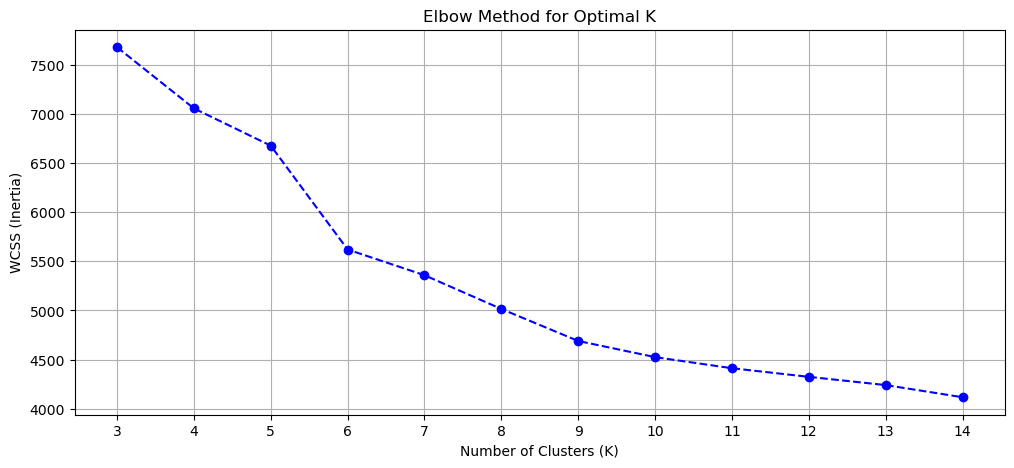

In [147]:
plt.figure(figsize = (12,5))
plt.plot(k,wcss,marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.xticks(k)
plt.show()

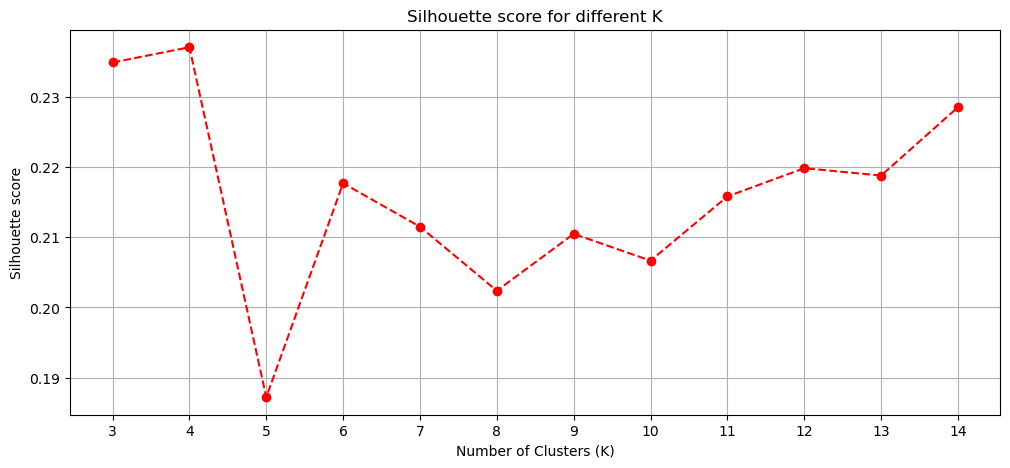

In [148]:
plt.figure(figsize = (12,5))
plt.plot(k,sil_score,marker='o', linestyle='--', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for different K')
plt.grid(True)
plt.xticks(k)
plt.show()

In [149]:
km_pca_ft = KMeans(n_clusters=4, random_state = 123).fit(pca_ft)
km_pca_ft_pred = km_pca_ft.predict(pca_ft)
km_pca_ft_pred[:10]

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0])

In [150]:
print('silhouette_score :',silhouette_score(pca_ft, km_pca_ft_pred))    

silhouette_score : 0.23706141504349681


In [151]:
# Based on elbow method and silhouette score optimal number of clusters are 4, 6, 7 or 9

### Profiling  

* Profilling should be done on original data ( without scalling, only till encoding on full data )
* profilling is used to identify characteristics of ssegments and identify optimal number of clusters 


In [152]:
telco_final.head(2)

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,tollfree,tollmon,voice,wireless,wiremon,region_2,region_3,custcat_2,custcat_3,custcat_4
0,9.0,44.0,1,0,0,7.50,0,0,4,5.0,...,0,0.00,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,7.0,33.0,1,1,1,15.25,1,0,5,5.0,...,1,20.75,1,1,35.7,0.0,1.0,0.0,0.0,1.0


In [153]:
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=1235)
    labels = km.fit_predict(pca_ft)
    
    col_name = f'KM{k}'
    telco_final[col_name] = labels

In [154]:
telco_final.head(3)

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,custcat_3,custcat_4,KM3,KM4,KM5,KM6,KM7,KM8,KM9,KM10
0,9.0,44.0,1,0,0,7.50,0,0,4,5.0,...,0.0,0.0,1,1,1,1,1,1,8,8
1,7.0,33.0,1,1,1,15.25,1,0,5,5.0,...,0.0,1.0,0,0,0,0,0,3,3,9
2,24.0,52.0,1,1,1,30.25,1,0,1,29.0,...,1.0,0.0,2,2,2,2,2,4,4,4


### check distribution of segments
* general guideiine that size of segment should be 5-40% (not less than 5% and not more than 40%)

In [155]:
# distribution of each segment 
telco_final.KM3.value_counts()/telco_final.KM3.value_counts().sum()

KM3
2    0.480
1    0.277
0    0.243
Name: count, dtype: float64

In [156]:
telco_final.KM4.value_counts()/telco_final.KM4.value_counts().sum()

KM4
2    0.320
3    0.306
0    0.203
1    0.171
Name: count, dtype: float64

In [157]:
telco_final.KM5.value_counts()/telco_final.KM5.value_counts().sum()

KM5
2    0.315
4    0.293
0    0.183
1    0.162
3    0.047
Name: count, dtype: float64

In [158]:
telco_final.KM6.value_counts()/telco_final.KM6.value_counts().sum()

KM6
2    0.301
4    0.282
0    0.167
1    0.155
3    0.048
5    0.047
Name: count, dtype: float64

In [159]:
telco_final.KM7.value_counts()/telco_final.KM7.value_counts().sum()

KM7
2    0.297
0    0.170
3    0.167
1    0.153
4    0.120
5    0.047
6    0.046
Name: count, dtype: float64

In [160]:
telco_final.KM8.value_counts()/telco_final.KM8.value_counts().sum()

KM8
1    0.186
4    0.166
2    0.152
0    0.145
7    0.137
3    0.119
6    0.048
5    0.047
Name: count, dtype: float64

In [161]:
telco_final.KM9.value_counts()/telco_final.KM9.value_counts().sum()

KM9
4    0.161
1    0.160
2    0.152
0    0.139
7    0.137
8    0.081
3    0.080
5    0.047
6    0.043
Name: count, dtype: float64

In [162]:
telco_final.KM10.value_counts()/telco_final.KM10.value_counts().sum()

KM10
2    0.152
0    0.139
7    0.137
8    0.132
4    0.110
3    0.084
9    0.078
1    0.078
5    0.047
6    0.043
Name: count, dtype: float64

In [163]:
# prepare how the data is distributed across different values of K.

seg_dist = pd.concat([pd.Series(telco_final.KM3.sum()) /telco_final.KM3.sum(),
                      telco_final.KM3.value_counts().sort_index()/telco_final.KM3.value_counts().sum(),
                      telco_final.KM4.value_counts().sort_index()/telco_final.KM4.value_counts().sum(),
                      telco_final.KM5.value_counts().sort_index()/telco_final.KM5.value_counts().sum(),
                      telco_final.KM6.value_counts().sort_index()/telco_final.KM6.value_counts().sum(),
                      telco_final.KM7.value_counts().sort_index()/telco_final.KM7.value_counts().sum(),
                      telco_final.KM8.value_counts().sort_index()/telco_final.KM8.value_counts().sum(),
                      telco_final.KM9.value_counts().sort_index()/telco_final.KM9.value_counts().sum(),
                      telco_final.KM10.value_counts().sort_index()/telco_final.KM10.value_counts().sum() ])

In [164]:
seg_dist_df = pd.DataFrame(seg_dist).T
seg_dist_df

,0,0,1,2,0,1,2,3,0,1,...,0,1,2,3,4,5,6,7,8,9
0,1.0,0.243,0.277,0.48,0.203,0.171,0.32,0.306,0.183,0.162,...,0.139,0.078,0.152,0.084,0.11,0.047,0.043,0.137,0.132,0.078


In [165]:
# get the segment wise average of all the features 
agg_summ = pd.concat([telco_final.mean(),
                      telco_final.groupby('KM3').mean().T,
                      telco_final.groupby('KM4').mean().T,
                      telco_final.groupby('KM5').mean().T,
                      telco_final.groupby('KM6').mean().T,
                      telco_final.groupby('KM7').mean().T,
                      telco_final.groupby('KM8').mean().T,
                      telco_final.groupby('KM9').mean().T,
                      telco_final.groupby('KM10').mean().T], axis = 1)

In [166]:
Profilling = pd.concat([seg_dist_df, agg_summ], axis = 0)
Profilling.columns = ['overall', 
                      'KM3_1','KM3_2','KM3_3',
                      'KM4_1','KM4_2','KM4_3','KM4_4',
                      'KM5_1','KM5_2','KM5_3','KM5_4','KM5_5',
                      'KM6_1','KM6_2','KM6_3','KM6_4','KM6_5','KM6_6',
                      'KM7_1','KM7_2','KM7_3','KM7_4','KM7_5','KM7_6','KM7_7',
                      'KM8_1','KM8_2','KM8_3','KM8_4','KM8_5','KM8_6','KM8_7','KM8_8',
                      'KM9_1','KM9_2','KM9_3','KM9_4','KM9_5','KM9_6','KM9_7','KM9_8','KM9_9',
                      'KM10_1','KM10_2','KM10_3','KM10_4','KM10_5','KM10_6','KM10_7','KM10_8','KM10_9','KM10_10']


In [167]:
Profilling.to_excel('Profilling.xlsx')

In [168]:
Profilling

,overall,KM3_1,KM3_2,KM3_3,KM4_1,KM4_2,KM4_3,KM4_4,KM5_1,KM5_2,...,KM10_1,KM10_2,KM10_3,KM10_4,KM10_5,KM10_6,KM10_7,KM10_8,KM10_9,KM10_10
0,1.000000,0.243000,0.277000,0.480000,0.203000,0.171000,0.320000,0.306000,0.183000,0.162000,...,0.139000,0.078000,0.152000,0.084000,0.110000,0.047000,0.043000,0.137000,0.132000,0.078000
address,11.543087,11.226337,13.007533,10.858333,11.467980,10.298246,10.034510,13.866155,11.704918,9.987654,...,11.179856,9.897436,11.447368,8.154762,10.390909,24.661419,18.441860,13.240876,10.113636,7.025641
age,41.683289,41.518519,44.181550,40.325000,41.645320,40.216374,40.547779,43.715686,42.420765,38.771605,...,41.640288,39.974359,40.072368,36.238095,41.109091,65.942328,56.232558,42.343066,38.719697,34.500000
callcard,0.678000,0.864198,0.635379,0.608333,0.871921,0.614035,0.575000,0.692810,0.890710,0.611111,...,0.863309,0.410256,0.644737,0.369048,0.781818,0.872340,0.883721,0.671533,0.583333,0.807692
callid,0.481000,0.814815,0.393502,0.362500,0.827586,0.456140,0.437500,0.310458,0.836066,0.456790,...,0.841727,0.102564,0.269737,0.119048,0.845455,0.553191,0.767442,0.284672,0.378788,0.820513
callwait,0.485000,0.798354,0.404332,0.372917,0.817734,0.438596,0.431250,0.346405,0.830601,0.438272,...,0.841727,0.089744,0.282895,0.083333,0.845455,0.595745,0.651163,0.357664,0.386364,0.794872
cardmon,13.686046,18.816191,12.671035,11.674655,19.387116,10.889136,10.957945,14.319859,20.132975,10.938532,...,19.052766,7.397436,12.192434,6.247024,15.570455,20.773074,19.634703,14.075126,10.426456,15.958333
confer,0.502000,0.806584,0.418773,0.395833,0.822660,0.479532,0.437500,0.369281,0.846995,0.469136,...,0.841727,0.141026,0.289474,0.119048,0.827273,0.638298,0.767442,0.386861,0.409091,0.756410
ebill,0.371000,0.674897,0.245487,0.289583,0.674877,0.210526,0.256250,0.379085,0.677596,0.216049,...,0.741007,0.435897,0.434211,0.285714,0.054545,0.191489,0.186047,0.408759,0.151515,0.576923
ed,2.671000,3.411523,2.321300,2.497917,3.477833,2.222222,2.312500,2.761438,3.464481,2.259259,...,3.446043,2.487179,2.980263,2.488095,2.045455,2.042553,2.837209,2.722628,2.090909,3.128205


### Predictions on new_data

In [169]:
new_data = pd.read_csv('Telco_new_cust.csv')
new_data.head(2)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,1,38,55,1,12,135,2,24,0,0,...,1,1,1,12.15,31.75,0.0,16.25,0.00,1,4
1,3,59,26,1,3,41,4,1,0,1,...,0,0,0,12.65,0.00,35.1,46.75,29.15,0,2


In [170]:
new_data.isna().sum()

region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
employ      0
retire      0
gender      0
reside      0
tollfree    0
equip       0
callcard    0
wireless    0
multline    0
voice       0
pager       0
internet    0
callid      0
callwait    0
forward     0
confer      0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
ebill       0
custcat     0
dtype: int64

In [171]:
new_data = new_data.apply(outliers)
new_data.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,1,38,55,1,12,135.0,2,24,0,0,...,1,1,1,12.15,31.75,0.00,16.25,0.00,1,4
1,3,59,26,1,3,41.0,4,1,0,1,...,0,0,0,12.65,0.00,35.10,46.75,29.15,0,2
2,2,54,55,0,1,587.0,3,33,0,0,...,1,1,1,13.00,0.00,0.00,0.00,0.00,0,3
3,3,9,40,0,13,38.0,4,7,0,1,...,1,1,1,3.35,21.00,42.40,17.50,59.55,1,4
4,1,67,67,1,38,49.0,2,10,0,1,...,0,0,0,14.30,0.00,29.25,25.25,0.00,1,2


In [172]:
ohe_new_df = pd.DataFrame(ohe.transform(new_data[['region', 'custcat']]).toarray(), columns = ohe.get_feature_names_out())
ohe_new_df

,region_2,region_3,custcat_2,custcat_3,custcat_4
0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
95,0.0,1.0,0.0,0.0,1.0
96,1.0,0.0,0.0,0.0,1.0
97,0.0,0.0,0.0,0.0,1.0
98,0.0,0.0,1.0,0.0,0.0


In [173]:
new_data = new_data[new_data.columns.difference(['region','custcat'])]
new_data

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,multline,pager,reside,retire,tenure,tollfree,tollmon,voice,wireless,wiremon
0,12,55,1,1,1,16.25,1,1,2,24,...,1,1,4.0,0,38,1,31.75,1,0,0.00
1,3,26,1,0,0,46.75,0,0,4,1,...,1,0,3.0,0,59,0,0.00,0,1,29.15
2,1,55,0,1,1,0.00,1,0,3,33,...,0,0,1.0,0,54,0,0.00,1,0,0.00
3,13,40,1,1,1,17.50,1,1,4,7,...,0,1,1.0,0,9,1,21.00,1,1,59.55
4,38,67,1,0,0,25.25,0,1,2,10,...,1,0,2.0,0,67,0,0.00,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,30,1,1,1,32.75,1,1,4,5,...,0,1,2.0,0,24,1,47.75,1,1,64.00
96,6,26,1,1,0,10.75,1,0,4,0,...,0,1,3.0,0,3,1,23.50,1,1,19.20
97,1,30,1,1,0,29.00,1,1,4,6,...,0,0,3.0,0,4,0,0.00,1,0,0.00
98,19,40,1,0,0,14.75,1,1,4,15,...,1,0,2.0,0,72,1,31.25,0,0,0.00


In [174]:
new_data = pd.concat([new_data, ohe_new_df],axis = 1)
new_data

,address,age,callcard,callid,callwait,cardmon,confer,ebill,ed,employ,...,tollfree,tollmon,voice,wireless,wiremon,region_2,region_3,custcat_2,custcat_3,custcat_4
0,12,55,1,1,1,16.25,1,1,2,24,...,1,31.75,1,0,0.00,0.0,0.0,0.0,0.0,1.0
1,3,26,1,0,0,46.75,0,0,4,1,...,0,0.00,0,1,29.15,0.0,1.0,1.0,0.0,0.0
2,1,55,0,1,1,0.00,1,0,3,33,...,0,0.00,1,0,0.00,1.0,0.0,0.0,1.0,0.0
3,13,40,1,1,1,17.50,1,1,4,7,...,1,21.00,1,1,59.55,0.0,1.0,0.0,0.0,1.0
4,38,67,1,0,0,25.25,0,1,2,10,...,0,0.00,0,0,0.00,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,30,1,1,1,32.75,1,1,4,5,...,1,47.75,1,1,64.00,0.0,1.0,0.0,0.0,1.0
96,6,26,1,1,0,10.75,1,0,4,0,...,1,23.50,1,1,19.20,1.0,0.0,0.0,0.0,1.0
97,1,30,1,1,0,29.00,1,1,4,6,...,0,0.00,1,0,0.00,0.0,0.0,0.0,0.0,1.0
98,19,40,1,0,0,14.75,1,1,4,15,...,1,31.25,0,0,0.00,0.0,0.0,1.0,0.0,0.0


In [175]:
new_data_scaled = pd.DataFrame(ss_telco.transform(new_data), columns = new_data.columns)
new_data_final = new_data_scaled[pca_ft.columns]
new_data_final

,wiremon,pager,custcat_3,age,multline,reside,region_2,income,retire,gender,multline
0,-0.594936,1.682682,-0.625156,1.061045,1.051315,1.175907,-0.708168,0.755890,-0.222076,-1.034598,1.051315
1,0.915184,-0.594289,-0.625156,-1.249609,1.051315,0.472905,-0.708168,-0.414643,-0.222076,0.966559,1.051315
2,-0.594936,-0.594289,1.599600,1.061045,-0.951190,-0.933100,1.412095,6.384411,-0.222076,-1.034598,-0.951190
3,2.490061,1.682682,-0.625156,-0.134121,-0.951190,-0.933100,-0.708168,-0.452000,-0.222076,0.966559,-0.951190
4,-0.594936,-0.594289,-0.625156,2.017178,1.051315,-0.230098,-0.708168,-0.315023,-0.222076,0.966559,1.051315
...,...,...,...,...,...,...,...,...,...,...,...
95,2.720594,1.682682,-0.625156,-0.930898,-0.951190,-0.230098,-0.708168,-0.613883,-0.222076,-1.034598,-0.951190
96,0.399723,1.682682,-0.625156,-1.249609,-0.951190,0.472905,1.412095,-0.190498,-0.222076,0.966559,-0.951190
97,-0.594936,-0.594289,-0.625156,-0.930898,-0.951190,0.472905,-0.708168,-0.364833,-0.222076,-1.034598,-0.951190
98,-0.594936,-0.594289,-0.625156,-0.134121,1.051315,-0.230098,-0.708168,1.104560,-0.222076,-1.034598,1.051315


In [193]:
km_pca_ft = KMeans(n_clusters=7, random_state = 123).fit(new_data_final)
km_pca_ft_pred = km_pca_ft.predict(new_data_final)
km_pca_ft_pred[:10]

array([3, 1, 4, 5, 1, 2, 1, 1, 3, 1])

In [194]:
silhouette_score(new_data_final, km_pca_ft_pred)

0.2052993423573493

In [195]:
new_data['KM_pred'] = km_pca_ft_pred
new_data['KM_pred'].value_counts()/new_data['KM_pred'].value_counts().sum()

KM_pred
2    0.26
1    0.23
0    0.17
3    0.15
5    0.09
4    0.07
6    0.03
Name: count, dtype: float64

In [198]:
pred_seg = new_data['KM_pred'].value_counts().sort_index()/new_data['KM_pred'].value_counts().sum()
pred_seg 

KM_pred
0    0.17
1    0.23
2    0.26
3    0.15
4    0.07
5    0.09
6    0.03
Name: count, dtype: float64